# Inflation Forecasting — AR-OLS + Random Walk

Simple, interpretable baselines for 1-month-ahead PCEPI monthly log-diff × 100:

- **AR-OLS** — OLS on 1–12 lags of the PCEPI series (univariate).
- **Naive random walk** — predict previous month's value.

Test split matches the other notebooks (`test_start='2025-06-01'`).
Predictions are saved to `results/` for `model_comparison.ipynb`.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

from fred_md_utils import (
    configure_plots, default_paths, get_splits,
    load_fred_md_raw,
    TEST_START, VAL_START,
)

warnings.filterwarnings('ignore')
configure_plots()
VINTAGE_DIR, RESULTS_DIR = default_paths()

AR_LAGS = 12


## Data Loading

In [2]:
# Shared split (matches other model notebooks exactly)
vintage_file, _, _, _, _, X_test, y_test, _ = get_splits(
    VINTAGE_DIR, horizon=1, n_lags=0,
)

# Univariate PCEPI log-diff x100 series (matches build_dataset_from_csv's target)
df_raw, _ = load_fred_md_raw(vintage_file)
pcepi_series = (np.log(df_raw['PCEPI']).diff() * 100).dropna()
pcepi_series.name = 'PCEPI_logdiff_x100'

test_dates = y_test.index
train_end_date = test_dates.min() - pd.DateOffset(months=1)

print(f'PCEPI series : {pcepi_series.index.min().date()} -> {pcepi_series.index.max().date()}  ({len(pcepi_series)} obs)')
print(f'Train end    : {train_end_date.date()}')
print(f'Test window  : {test_dates.min().date()} -> {test_dates.max().date()}   n_test = {len(test_dates)}')


  2026-04-MD.csv: URL returned HTML — vintage not yet published
Already have 2026-03-MD.csv

Dataset summary (PCEPI first-log-diff target, 1-month-ahead):
  Train :  768 obs  1959-01-01 -> 2022-12-01
  Val   :   29 obs  2023-01-01 -> 2025-05-01
  Test  :    7 obs  2025-06-01 -> 2025-12-01
  Features: 126 (126 base × 1 time steps)
PCEPI series : 1959-02-01 -> 2026-01-01  (804 obs)
Train end    : 2025-05-01
Test window  : 2025-06-01 -> 2025-12-01   n_test = 7


## Model 1 — AR-OLS (PCEPI lags only)

Plain OLS with 12 lags of the PCEPI log-diff series.

In [3]:
def build_lag_matrix(series, lags):
    df = pd.DataFrame({f'lag{i}': series.shift(i) for i in range(1, lags + 1)})
    df['y'] = series
    return df.dropna()

ar_df = build_lag_matrix(pcepi_series, AR_LAGS)
ar_train = ar_df.loc[:train_end_date]

X_ar = sm.add_constant(ar_train.drop(columns='y'))
y_ar = ar_train['y']
ar_res = sm.OLS(y_ar, X_ar).fit()
print(ar_res.summary().tables[1])

ar_preds = []
for date in test_dates:
    row = ar_df.loc[date].drop('y')
    xrow = np.concatenate([[1.0], row.values])
    ar_preds.append(float(ar_res.params.values @ xrow))

ar_preds = np.array(ar_preds)
ar_rmse = np.sqrt(mean_squared_error(y_test.values, ar_preds))
print(f'AR-OLS({AR_LAGS}) test RMSE: {ar_rmse:.4f}')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0276      0.010      2.712      0.007       0.008       0.048
lag1           0.4648      0.036     12.964      0.000       0.394       0.535
lag2           0.0053      0.039      0.135      0.893      -0.072       0.083
lag3           0.0614      0.039      1.556      0.120      -0.016       0.139
lag4           0.0676      0.039      1.714      0.087      -0.010       0.145
lag5           0.0395      0.040      1.000      0.318      -0.038       0.117
lag6           0.0708      0.039      1.794      0.073      -0.007       0.148
lag7           0.0691      0.040      1.749      0.081      -0.008       0.147
lag8          -0.0091      0.040     -0.230      0.818      -0.087       0.069
lag9           0.0761      0.039      1.929      0.054      -0.001       0.153
lag10          0.0480      0.039      1.218      0.2

## Model 2 — Naive random walk

In [4]:
naive_preds = []
for date in test_dates:
    prev_date = date - pd.DateOffset(months=1)
    if prev_date in pcepi_series.index:
        naive_preds.append(float(pcepi_series.loc[prev_date]))
    else:
        naive_preds.append(float(pcepi_series.iloc[-1]))

naive_preds = np.array(naive_preds)
naive_rmse = np.sqrt(mean_squared_error(y_test.values, naive_preds))
print(f'Naive random walk test RMSE: {naive_rmse:.4f}')

Naive random walk test RMSE: 0.0801


## Metrics Table + Overlay Plot

Test period: 2025-06-01 -> 2025-12-01   n = 7
Metrics scale: monthly log-diff x 100 (pp of monthly PCE inflation)

              Model   RMSE    MAE      R2  MAPE (%)
         AR-OLS(12) 0.0545 0.0420  0.0874   16.2219
Naive (random walk) 0.0801 0.0646 -0.9664   24.1647


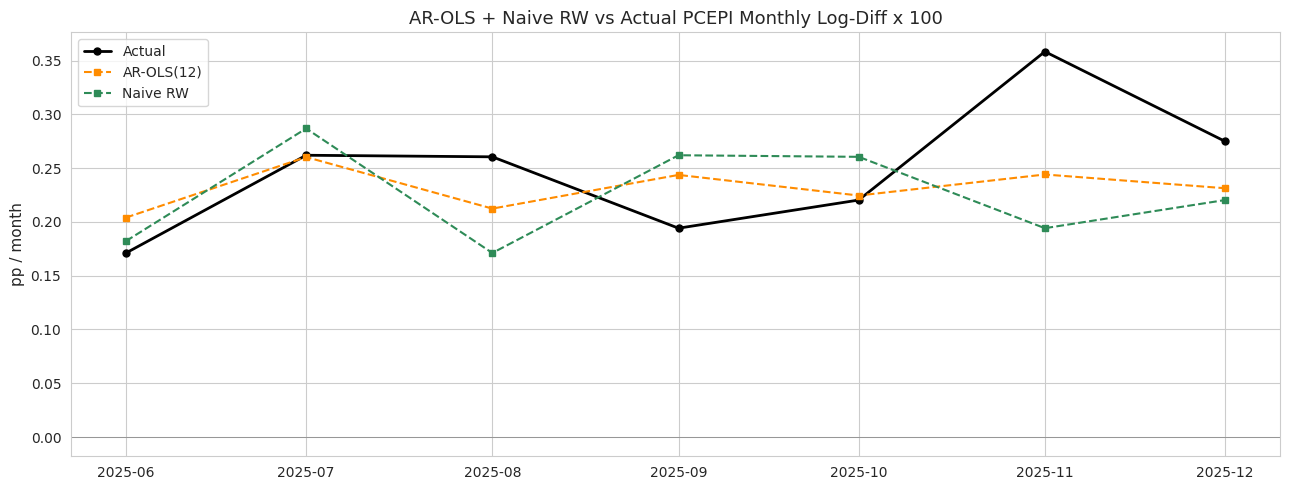

In [5]:
def metrics(name, y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return {
        'Model':    name,
        'RMSE':     float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':      float(mean_absolute_error(y_true, y_pred)),
        'R2':       float(r2_score(y_true, y_pred)),
        'MAPE (%)': float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100),
    }

results_df = pd.DataFrame([
    metrics(f'AR-OLS({AR_LAGS})', y_test.values, ar_preds),
    metrics('Naive (random walk)', y_test.values, naive_preds),
]).sort_values('RMSE').reset_index(drop=True)

print(f'Test period: {test_dates.min().date()} -> {test_dates.max().date()}   n = {len(test_dates)}')
print('Metrics scale: monthly log-diff x 100 (pp of monthly PCE inflation)')
print()
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_test.values, 'o-', color='black', label='Actual', linewidth=2, markersize=5)
ax.plot(test_dates, ar_preds,    's--', color='darkorange', label=f'AR-OLS({AR_LAGS})', markersize=5)
ax.plot(test_dates, naive_preds, 's--', color='seagreen',   label='Naive RW', markersize=5)
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title('AR-OLS + Naive RW vs Actual PCEPI Monthly Log-Diff x 100')
ax.set_ylabel('pp / month')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.tight_layout()
plt.show()

## Save Predictions for `model_comparison.ipynb`

In [6]:
dates_arr = np.array(test_dates, dtype='datetime64[ns]')

np.save(os.path.join(RESULTS_DIR, 'ar_ols_preds.npy'), ar_preds)
np.save(os.path.join(RESULTS_DIR, 'ar_ols_dates.npy'), dates_arr)

np.save(os.path.join(RESULTS_DIR, 'naive_preds.npy'),  naive_preds)
np.save(os.path.join(RESULTS_DIR, 'naive_dates.npy'),  dates_arr)

# Clean up stale MV-OLS artifacts from earlier runs
for k in ['mv_ols_preds', 'mv_ols_dates']:
    p = os.path.join(RESULTS_DIR, f'{k}.npy')
    if os.path.exists(p):
        os.remove(p)
        print(f'Removed stale {p}')

print('Saved to results/:')
for k in ['ar_ols_preds', 'ar_ols_dates', 'naive_preds', 'naive_dates']:
    p = os.path.join(RESULTS_DIR, f'{k}.npy')
    print(f'  {p}   shape = {np.load(p, allow_pickle=False).shape}')

Saved to results/:
  results/ar_ols_preds.npy   shape = (7,)
  results/ar_ols_dates.npy   shape = (7,)
  results/naive_preds.npy   shape = (7,)
  results/naive_dates.npy   shape = (7,)
